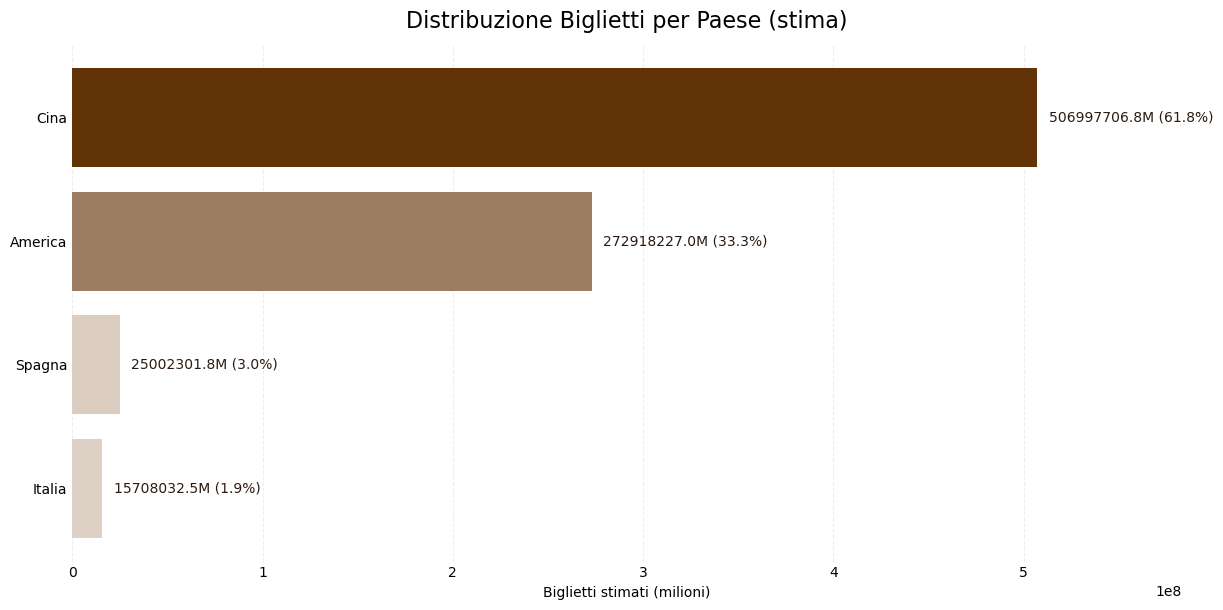

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.colors import to_rgb

def parse_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["", "-", "nan", "none"]:
        return np.nan
    s = s.replace("€", "").replace("$", "")
    s = re.sub(r"[^\d.,]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

raw = pd.read_csv("Nazione.csv")
raw.columns = raw.columns.str.strip()

header_row = raw.iloc[0].tolist()
cols = []
for i, c in enumerate(raw.columns):
    v = header_row[i]
    v = "" if pd.isna(v) else str(v).strip()
    cols.append(v if v != "" else str(c).strip())

df = raw.iloc[1:].copy()
df.columns = cols
df = df.loc[:, [c for c in df.columns if not str(c).lower().startswith("unnamed")]]

col_film = df.columns[0]
df = df.rename(columns={col_film: "Movie"})
df["Movie"] = df["Movie"].astype(str).str.strip()

for c in df.columns:
    if c != "Movie":
        df[c] = df[c].apply(parse_num)

df = df.fillna(0.0)

prezzi_raw = pd.read_csv("PrezzoMedioTickets.csv")
prezzi_raw.columns = prezzi_raw.columns.str.strip()
prezzi = {}
for c in prezzi_raw.columns:
    prezzi[c.strip()] = parse_num(prezzi_raw.iloc[0][c])

def norm_paese(s):
    s = str(s).strip().lower()
    s = s.replace("stati uniti", "america")
    s = s.replace("usa", "america")
    s = s.replace("united states", "america")
    s = s.replace("italy", "italia")
    s = s.replace("spain", "spagna")
    s = s.replace("china", "cina")
    s = s.replace("uk", "regno unito")
    s = s.replace("united kingdom", "regno unito")
    s = s.replace("germany", "germania")
    return s

m_inc = {norm_paese(c): c for c in df.columns if c != "Movie"}
m_pre = {norm_paese(c): c for c in prezzi.keys()}

chiavi = sorted(list(set(m_inc.keys()).intersection(set(m_pre.keys()))))

if len(chiavi) == 0:
    chiavi = [k for k in m_inc.keys() if k in m_pre.keys()]

incassi_paese = {}
prezzo_paese = {}
for k in chiavi:
    c_inc = m_inc[k]
    c_pre = m_pre[k]
    incassi_paese[k] = float(df[c_inc].sum())
    prezzo_paese[k] = float(prezzi[c_pre]) if prezzi[c_pre] is not None else np.nan

serie_inc = pd.Series(incassi_paese).replace([np.inf, -np.inf], np.nan).fillna(0.0)
serie_pre = pd.Series(prezzo_paese).replace([np.inf, -np.inf], np.nan)

validi = (serie_inc > 0) & (serie_pre > 0)
serie_inc = serie_inc[validi]
serie_pre = serie_pre[validi]

tickets_mln = (serie_inc / serie_pre)
tickets_mln = tickets_mln.sort_values(ascending=True)

etichette = {
    "america": "America",
    "italia": "Italia",
    "cina": "Cina",
    "spagna": "Spagna",
    "regno unito": "Regno Unito",
    "germania": "Germania",
    "giappone": "Giappone",
    "malesia": "Malaysia",
    "singapore": "Singapore"
}

paesi = [etichette.get(k, k.title()) for k in tickets_mln.index]
valori = tickets_mln.values

tot = float(np.sum(valori))
pct = 100 * valori / tot if tot > 0 else np.zeros_like(valori)

base_hex = "#633308"
base_rgb = np.array(to_rgb(base_hex))
light_rgb = np.array(to_rgb("#f3ede6"))

vmin, vmax = float(np.min(valori)), float(np.max(valori))
if vmax == vmin:
    colori = [tuple(base_rgb) for _ in valori]
else:
    t = (valori - vmin) / (vmax - vmin)
    t = 0.15 + 0.85 * t
    colori = [tuple(light_rgb*(1-ti) + base_rgb*ti) for ti in t]

fig, ax = plt.subplots(figsize=(12.5, 6.2))

y = np.arange(len(paesi))
bars = ax.barh(y, valori, color=colori, edgecolor="none")

ax.set_title("Distribuzione Biglietti per Paese (stima)", fontsize=16, pad=12)
ax.set_xlabel("Biglietti stimati (milioni)")
ax.set_yticks(y)
ax.set_yticklabels(paesi)

ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.22)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

pad = max(valori) * 0.012 if len(valori) else 0.0
for b, v, p in zip(bars, valori, pct):
    ax.text(v + pad, b.get_y() + b.get_height()/2, f"{v:.1f}M ({p:.1f}%)", va="center", fontsize=10, color="#2b1a10")

ax.set_xlim(0, max(valori) * 1.15)

plt.tight_layout()
plt.show()